BUSINESS PROBLEM



A Global e-commerce company operating accross multiple reason manages end-to-end order fulfilment, including shipping and delivery, for products like sporting goods. The company is facing inconsistent delivery performance, where actual shipping time often deviates fron scheduled timelines, leading to late deliveries and unpredictable order profitability.

DESIRED Outcome:

The goal is to analyze delivery operations, identify bottlenecks, and build a predictive system to reduce delays, optimize shipping decisions, and overall profitability and efficiency.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
# Set professional color theme
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

viridis_colors = cm.viridis(np.linspace(0,1,5))
primary_color = viridis_colors[4]
secondary_color = viridis_colors[1]
accent_color = viridis_colors[2]
danger_color = '#800000'
neutral_color = viridis_colors[4]
custom_palette = viridis_colors

In [3]:
df = pd.read_csv('DataCoSupplyChainDataset.csv',encoding='latin-1')

Exploratory Data Analysis (EDA)

In [6]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

In [10]:
print("rows, cols",df.shape)

rows, cols (180519, 53)


In [11]:
print(df.columns.tolist())

['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product Status', 'shipping date (DateOrde

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [16]:
print("Missing top 10 Values:")
print(df.isna().sum().sort_values(ascending=False).head(10))

Missing top 10 Values:
Product Description              180519
Order Zipcode                    155679
Customer Lname                        8
Customer Zipcode                      3
Days for shipment (scheduled)         0
Sales per customer                    0
Benefit per order                     0
Delivery Status                       0
Late_delivery_risk                    0
Customer City                         0
dtype: int64


In [20]:
print("Duplicated Rows:", df.duplicated().sum())

Duplicated Rows: 0


In [21]:
columns_to_drop = [
    'Product Description',
    'Product Image',
    'Customer Email',
    'Customer Password',
    'Customer Fname',
    'Customer Lname',
    'Customer Street',
    'Customer Zipcode',
    'Order Zipcode',
    'Longitude',
    'Latitude',
    'Order Item Cardprod Id',
    'Order Item Id',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Quantity',
    'Order Item Total',
    'Category Id',
    'Department Id',
    'Order Id',
    'Order Customer Id',
    'Customer Id',
    'Product Card Id',
    'Product Category Id',
    'Benefit per order',      # identical to Order Profit Per Order
    'Product Status',         # only one unique value
    'Customer City',
    'Order City',
    'Order Country',
    'Order State',
    'Customer State',
    'Market'
]

# Drop unnecessary columns
df = df.drop(columns=columns_to_drop)

In [22]:
# Remove cancelled orders
df = df[df['Delivery Status'] != 'Shipping canceled']

In [23]:
# Convert date columns
for c in ['order date (DateOrders)', 'shipping date (DateOrders)']:
    df[c] = pd.to_datetime(df[c], errors='coerce', dayfirst=False)

In [24]:
# Check dataset after cleaning
print("Rows, cols:", df.shape)

print("\nMissing values (Top 5):")
print(df.isna().sum().sort_values(ascending=False).head(5))

Rows, cols: (172765, 20)

Missing values (Top 5):
Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Sales per customer               0
Delivery Status                  0
dtype: int64


In [25]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,Department Name,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Order Region,Order Status,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-31 22:56:00,0.29,327.75,91.250000,Southeast Asia,COMPLETE,Smart watch,327.75,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-13 12:27:00,-0.80,327.75,-249.089996,South Asia,PENDING,Smart watch,327.75,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,Fitness,2018-01-13 12:06:00,-0.80,327.75,-247.779999,South Asia,CLOSED,Smart watch,327.75,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,Fitness,2018-01-13 11:45:00,0.08,327.75,22.860001,Oceania,COMPLETE,Smart watch,327.75,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,Fitness,2018-01-13 11:24:00,0.45,327.75,134.210007,Oceania,PENDING_PAYMENT,Smart watch,327.75,2018-01-15 11:24:00,Standard Class


In [31]:
# value counts for categorical columns with low cardinality.
for c in df.columns:
    if df[c].nunique()<10:
        print(f"\nValue counts for column '{c}':")
        print(df[c].value_counts())


Value counts for column 'Type':
Type
DEBIT       69295
TRANSFER    42129
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Value counts for column 'Days for shipping (real)':
Days for shipping (real)
2    54205
6    27489
3    27478
4    27297
5    27003
0     4839
1     4454
Name: count, dtype: int64

Value counts for column 'Days for shipment (scheduled)':
Days for shipment (scheduled)
4    103153
2     33806
1     26513
0      9293
Name: count, dtype: int64

Value counts for column 'Delivery Status':
Delivery Status
Late delivery       98977
Advance shipping    41592
Shipping on time    32196
Name: count, dtype: int64

Value counts for column 'Late_delivery_risk':
Late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64

Value counts for column 'Customer Country':
Customer Country
EE. UU.        106425
Puerto Rico     66340
Name: count, dtype: int64

Value counts for column 'Customer Segment':
Customer Segment
Consumer       89420
Corporate      52528
Home Of

In [32]:
# calculating order processing time and delay

df['Order Processing Time'] = (df['shipping date (DateOrders)'] - df['order date (DateOrders)']).dt.days
df['Order Processing Time'] = (df['shipping date (DateOrders)'] - df['order date (DateOrders)']).dt.days
df['Delay'] = df['Order Processing Time'] - df['Days for shipment (scheduled)']
df['Is_Delayed'] = df['Delay'] > 0
df['order_month'] = df['order date (DateOrders)'].dt.month
df['order_day'] = df['order date (DateOrders)'].dt.day_name()
df['order_hour'] = df['order date (DateOrders)'].dt.hour
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Product Price,shipping date (DateOrders),Order Processing Time,Delay,order_month,order_hour
count,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000
mean,3.498596,2.933100,183.165948,0.572900,2016-06-12 15:25:39.457991936,0.120801,203.828493,22.032360,141.278595,2016-06-16 03:25:14.452927488,3.472816,0.539716,6.235511,11.482604
min,0.000000,0.000000,7.490000,0.000000,2015-01-01 00:00:00,-2.750000,9.990000,-4274.979980,9.990000,2015-01-03 00:00:00,0.000000,-2.000000,1.000000,0.000000
25%,2.000000,2.000000,104.379997,0.000000,2015-09-21 18:01:00,0.080000,119.980003,7.030000,50.000000,2015-09-25 08:59:00,2.000000,0.000000,3.000000,5.000000
50%,3.000000,4.000000,163.990005,1.000000,2016-06-11 08:11:00,0.270000,199.919998,31.520000,59.990002,2016-06-15 03:38:00,3.000000,1.000000,6.000000,11.000000
75%,5.000000,4.000000,247.399994,1.000000,2017-02-28 21:08:00,0.360000,299.950012,64.800003,199.990005,2017-03-04 08:00:00,5.000000,1.000000,9.000000,17.000000
max,6.000000,4.000000,1939.989990,1.000000,2018-01-31 23:38:00,0.500000,1999.989990,911.799988,1999.989990,2018-02-06 22:14:00,6.000000,4.000000,12.000000,23.000000
std,1.623446,1.373405,120.141871,0.494659,NaN,0.466610,132.392520,104.355313,139.862956,NaN,1.670187,1.494150,3.405593,6.927276


In [33]:
df['Is_Delayed'].value_counts()

Is_Delayed
True     94523
False    78242
Name: count, dtype: int64

In [34]:
# Profitability Flag based on Order Profit Per Order
df['Profitability Flag'] = np.where(df['Order Profit Per Order'] > 0, 'Profit', np.where(df['Order Profit Per Order'] < 0, 'Loss','break-even'))
df['Profitability Flag'].value_counts()

Profitability Flag
Profit        139354
Loss           32295
break-even      1116
Name: count, dtype: int64

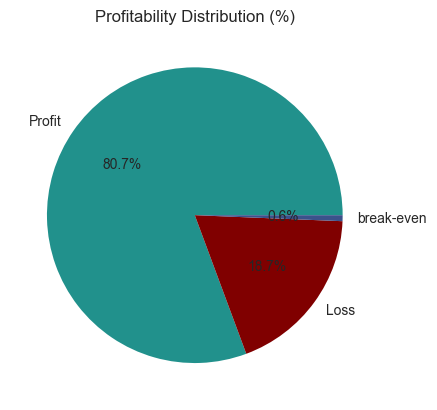

In [48]:
# Visualisation of probability distribution
profit_counts = df['Profitability Flag'].value_counts(normalize=True)* 100
profit_counts.plot(kind='pie', autopct='%1.1f%%', colors=[accent_color, danger_color, secondary_color])
plt.ylabel('')
plt.title('Profitability Distribution (%)')
plt.show()


In [49]:
# KPIs

def format_func(value):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'

delayed_df = df[df['Delay'] > 0]
metrics = {}
metrics['Total Orders'] = len(df)
metrics['Late Deliveries'] = len(delayed_df)
metrics['90% Delay (days)'] = delayed_df['Delay'].quantile(0.90)
metrics['On time Delivery % '] = (1 - float(metrics['Late Deliveries'])/metrics['Total Orders']) * 100
metrics['Late Delivery % '] = float(metrics['Late Deliveries'])/metrics['Total Orders'] * 100
metrics['Total Profit'] = format_func(df.loc[df['Order Profit Per Order'] > 0, 'Order Profit Per Order'].sum())
metrics['Total Loss due to delays'] = format_func(df.loc[df['Delay'] > 0, 'Order Profit Per Order'].sum())

print('\n---- Business KPIs ----\n')
for k,v in metrics.items():
    if isinstance(v, float):
        print(f"{k}:{v:.2f}")
    else:
        print(f"{k}: {v}")


---- Business KPIs ----

Total Orders: 172765
Late Deliveries: 94523
90% Delay (days):3.00
On time Delivery % :45.29
Late Delivery % :54.71
Total Profit: 7.5M $
Total Loss due to delays: 2.1M $


In [50]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,Department Name,...,Product Price,shipping date (DateOrders),Shipping Mode,Order Processing Time,Delay,Is_Delayed,order_month,order_day,order_hour,Profitability Flag
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,Fitness,...,327.75,2018-02-03 22:56:00,Standard Class,3,-1,False,1,Wednesday,22,Profit
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,Fitness,...,327.75,2018-01-18 12:27:00,Standard Class,5,1,True,1,Saturday,12,Loss
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,Fitness,...,327.75,2018-01-17 12:06:00,Standard Class,4,0,False,1,Saturday,12,Loss
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,Fitness,...,327.75,2018-01-16 11:45:00,Standard Class,3,-1,False,1,Saturday,11,Profit
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,Fitness,...,327.75,2018-01-15 11:24:00,Standard Class,2,-2,False,1,Saturday,11,Profit


Profitability vs Delivery Time Analysis

In [53]:
profit_metrics = (
    df.groupby('Delay')['Order Profit Per Order'].agg(
        mean_profit='mean',
        total_profit='sum',
        order_count='count'
    )
    .reset_index()
)

In [54]:
profit_metrics

,Delay,mean_profit,total_profit,order_count
0,-2,23.360134,4.875961e+05,20873
1,-1,21.604769,4.476292e+05,20719
2,0,22.249118,8.154302e+05,36650
3,1,22.333227,1.194895e+06,53503
4,2,21.128491,5.821110e+05,27551
5,3,20.031412,1.356527e+05,6772
6,4,21.368783,1.431067e+05,6697


In [60]:
delay_distribution = (
    df['Delay'].value_counts(normalize=True)
    .sort_index() * 100
).reset_index()

In [62]:
delay_distribution

,Delay,proportion
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364



Profit Metrics by Delay Day: 


,Delay,mean_profit,total_profit,order_count
0,-2,23.4,487596.1,20873
1,-1,21.6,447629.2,20719
2,0,22.2,815430.2,36650
3,1,22.3,1194894.7,53503
4,2,21.1,582111.0,27551
5,3,20.0,135652.7,6772
6,4,21.4,143106.7,6697



 Delay Distribution (%): 


,Delay_Days,Percentage
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364


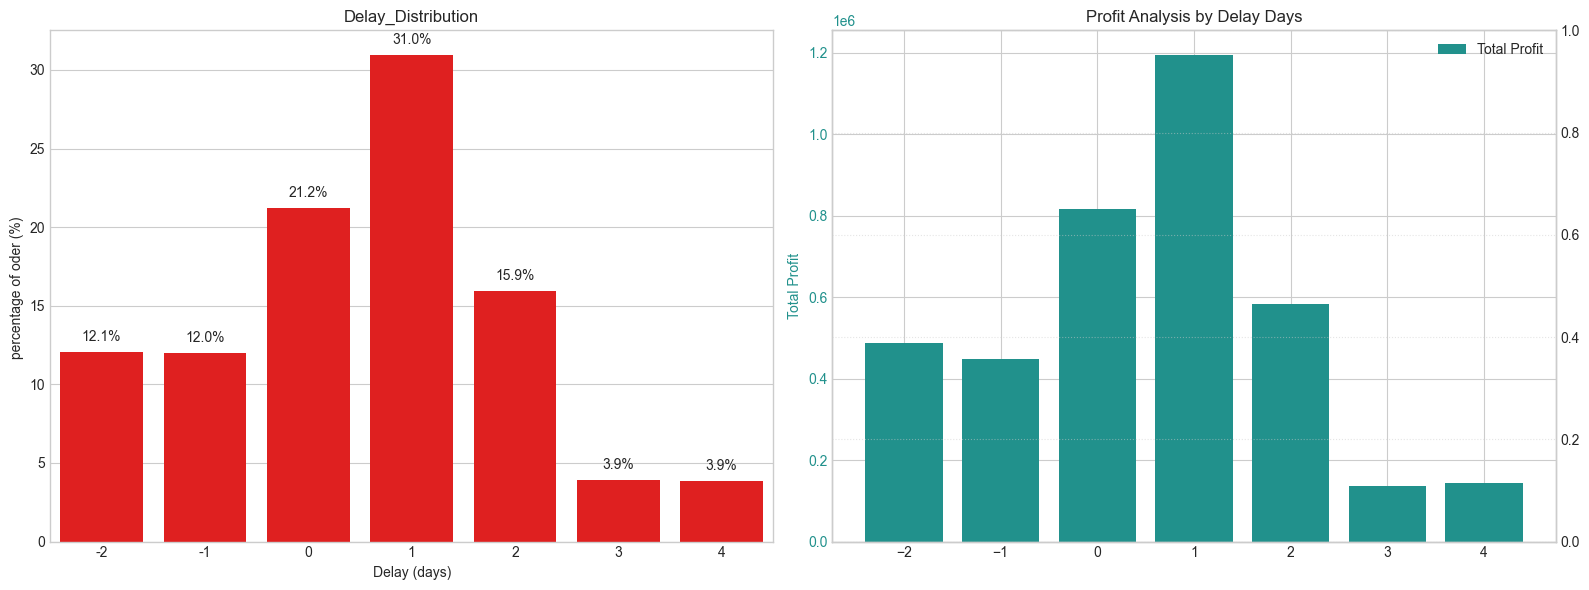

In [73]:
delay_distribution.columns = ['Delay_Days','Percentage']

print("\nProfit Metrics by Delay Day: ")
display(profit_metrics.round(1))

print("\n Delay Distribution (%): ")
display(delay_distribution)

fig, (ax1, ax2) = plt.subplots(1,2,figsize=(16,6))

# First subplot: Delay_Distribution
sns.barplot(x='Delay_Days', y='Percentage', data=delay_distribution, color = "red", ax=ax1)
ax1.set_title('Delay_Distribution')
ax1.set_xlabel('Delay (days)')
ax1.set_ylabel('percentage of oder (%) ')

# percentage text on bars
for bar in ax1.patches:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.1f}%', ha='center',va='bottom')

# Second subplot: Profit Analysis by Delay Days
ax2.set_ylabel("Total Profit", color=accent_color)
ax2.bar(profit_metrics['Delay'], profit_metrics['total_profit'], color=accent_color, label='Total Profit')
ax2.tick_params(axis='y', labelcolor=accent_color)

ax3 = ax2.twinx()
ax3.set_title("Profit Analysis by Delay Days")

lines, labels = ax3.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax3.legend(lines + lines2, labels + labels2, loc='upper right')
ax3.grid(True, linestyle=':',alpha=0.5)

plt.tight_layout()
plt.show()

Bottleneck Detection

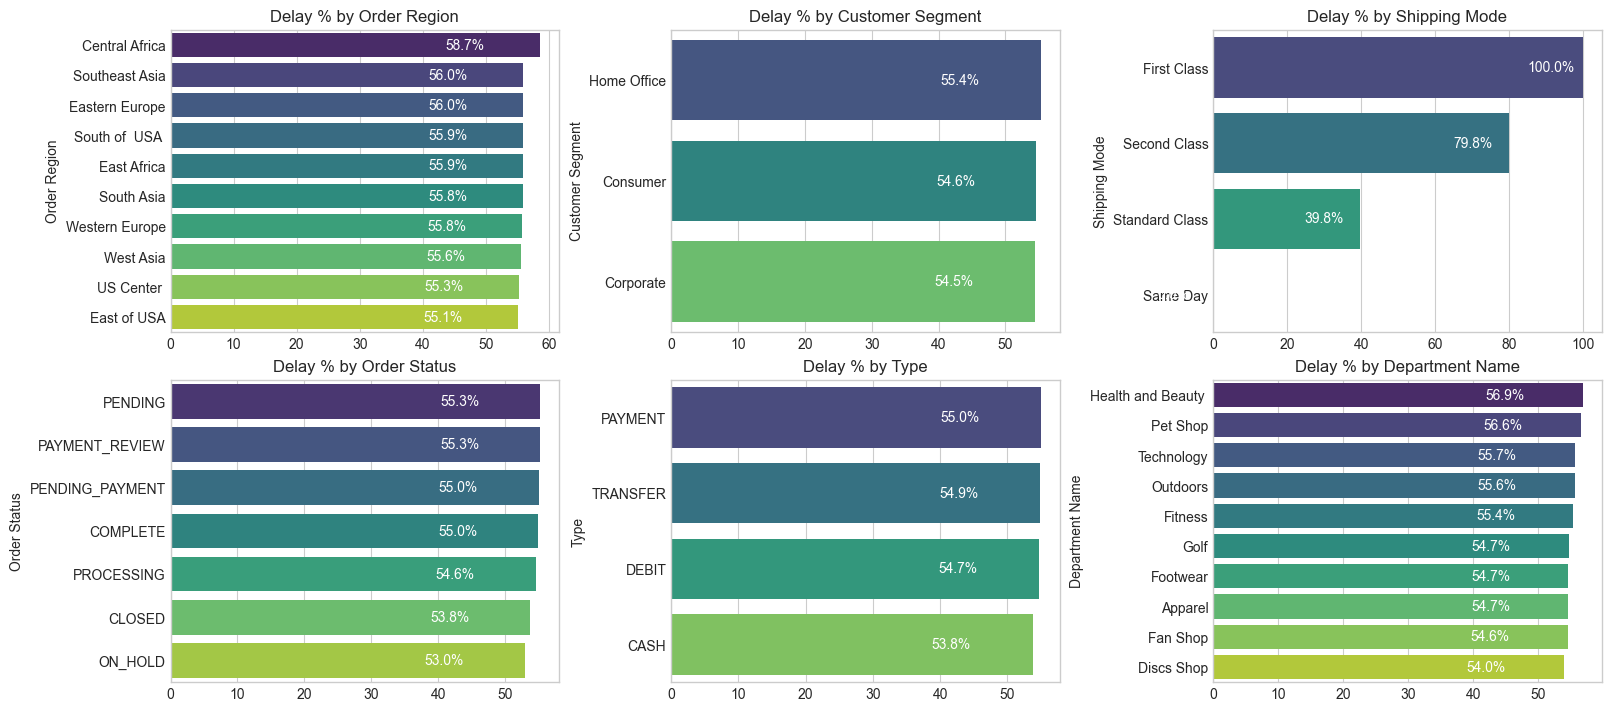

In [74]:
def compute_delay_pct_by_category(category):
    cat_df = df.groupby(category).agg(
        total_orders=('Delay','count'),
        late_orders=('Is_Delayed','sum')
    ).reset_index()
    cat_df['delay_pct'] = cat_df['late_orders']/cat_df['total_orders'] * 100
    cat_df = cat_df.sort_values('delay_pct', ascending=False).head(10)
    return cat_df

categories = ['Order Region', 'Customer Segment','Shipping Mode','Order Status','Type','Department Name']
fig,axes = plt.subplots(2,3, figsize=(16, 7), constrained_layout=True)
axes = axes.flatten()

for ax, category in zip(axes, categories):
    cat_df = compute_delay_pct_by_category(category)
    sns.barplot(data=cat_df, x = 'delay_pct', y=category, ax=ax, palette='viridis')

    ax.set_title(f'Delay % by {category}')
    ax.set_xlabel('')
    ax.set_ylabel(category)
    for i, row in cat_df.reset_index().iterrows():
        ax.text(row['delay_pct'] - 15, i, f"{row['delay_pct']:.1f}%", va='center', fontsize=10, color='white')

plt.show()
    

Root Cause Analysis

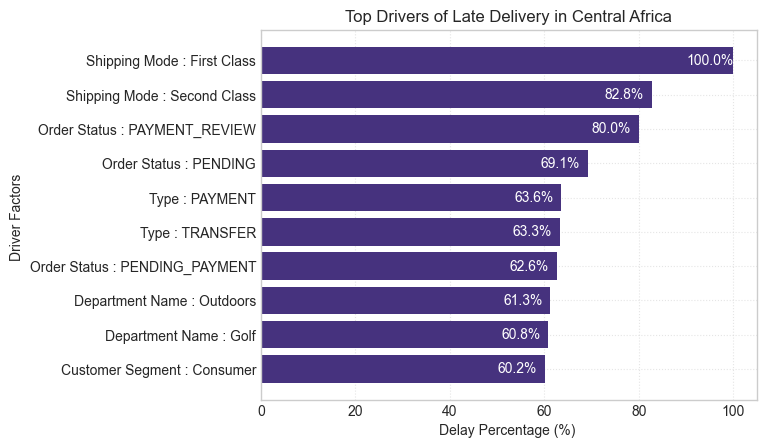

In [75]:
# Top drivers of late delivery by region

def top_drivers_for_region(region):
    df_region = df[df['Order Region'] == region].copy()

    drivers = ['Shipping Mode','Customer Segment','Department Name','Type','Order Status']
    all_factors = []
    for factor in drivers:
        temp=(
            df_region.groupby(factor).agg(
                total_orders=('Delay','count'),
                late_orders=('Is_Delayed','sum'),
                avg_delay=('Delay','mean')
            )
            .reset_index()
        )

        temp['delay_pct'] =temp['late_orders']/temp['total_orders'] *100
        temp['Driver'] = factor
        temp['Factor_Level'] = factor + " : " + temp[factor].astype(str)

        all_factors.append(temp[['Driver','Factor_Level','delay_pct','avg_delay','total_orders']])

    # Combine all drivers
    final_df = pd.concat(all_factors,ignore_index=True)

    # Top 10 drivers
    top_factors = final_df.sort_values('delay_pct',ascending=False).head(10)
    plt.figure()

    bars = plt.barh(top_factors['Factor_Level'],top_factors['delay_pct'])

    plt.xlabel("Delay Percentage (%) ")
    plt.ylabel("Driver Factors ")
    plt.title(f"Top Drivers of Late Delivery in {region}")
    plt.grid(True, linestyle=':',alpha=0.5)
    plt.gca().invert_yaxis()
    for bar in bars:
        width = bar.get_width()
        plt.text(width - 10, bar.get_y() + bar.get_height()/2,
                f"{width:.1f}%",
                va ='center', fontsize=10, color='white')
    plt.show()

top_drivers_for_region('Central Africa')

In [76]:
df['order date (DateOrders)'].min()

Timestamp('2015-01-01 00:00:00')

In [77]:
df['order date (DateOrders)'].max()

Timestamp('2018-01-31 23:38:00')

Time Based Analysis

In [78]:
# Delay % by Month, Day of Week, Hour

delay_by_month = (
    df.groupby('order_month')['Is_Delayed']
    .mean()
    .reset_index()
)

delay_by_month['delay_pct'] = delay_by_month['Is_Delayed'] * 100

delay_by_day = (
    df.groupby('order_day')['Is_Delayed']
    .mean()
    .reset_index()
)
delay_by_day['delay_pct'] = delay_by_day['Is_Delayed'] * 100

delay_by_hour = (
    df.groupby('order_hour')['Is_Delayed']
    .mean()
    .reset_index()
)
delay_by_hour['delay_pct'] = delay_by_hour['Is_Delayed'] * 100


In [79]:
delay_by_month

,order_month,Is_Delayed,delay_pct
0,1,0.542542,54.254150
1,2,0.546046,54.604550
2,3,0.548094,54.809390
3,4,0.545042,54.504230
4,5,0.549980,54.998022
5,6,0.547645,54.764535
6,7,0.537310,53.731048
7,8,0.553871,55.387128
8,9,0.553885,55.388454
9,10,0.540970,54.097044


In [81]:
delay_by_day

,order_day,Is_Delayed,delay_pct
0,Friday,0.544884,54.488442
1,Monday,0.555338,55.533838
2,Saturday,0.542619,54.261937
3,Sunday,0.551524,55.152418
4,Thursday,0.547202,54.720188
5,Tuesday,0.539841,53.984137
6,Wednesday,0.548452,54.845175


In [82]:
delay_by_hour

,order_hour,Is_Delayed,delay_pct
0,0,0.540686,54.068641
1,1,0.554227,55.422680
2,2,0.551937,55.193735
3,3,0.541420,54.142012
4,4,0.536747,53.674683
5,5,0.552672,55.267154
6,6,0.528388,52.838802
7,7,0.549882,54.988239
8,8,0.531329,53.132903
9,9,0.543575,54.357480


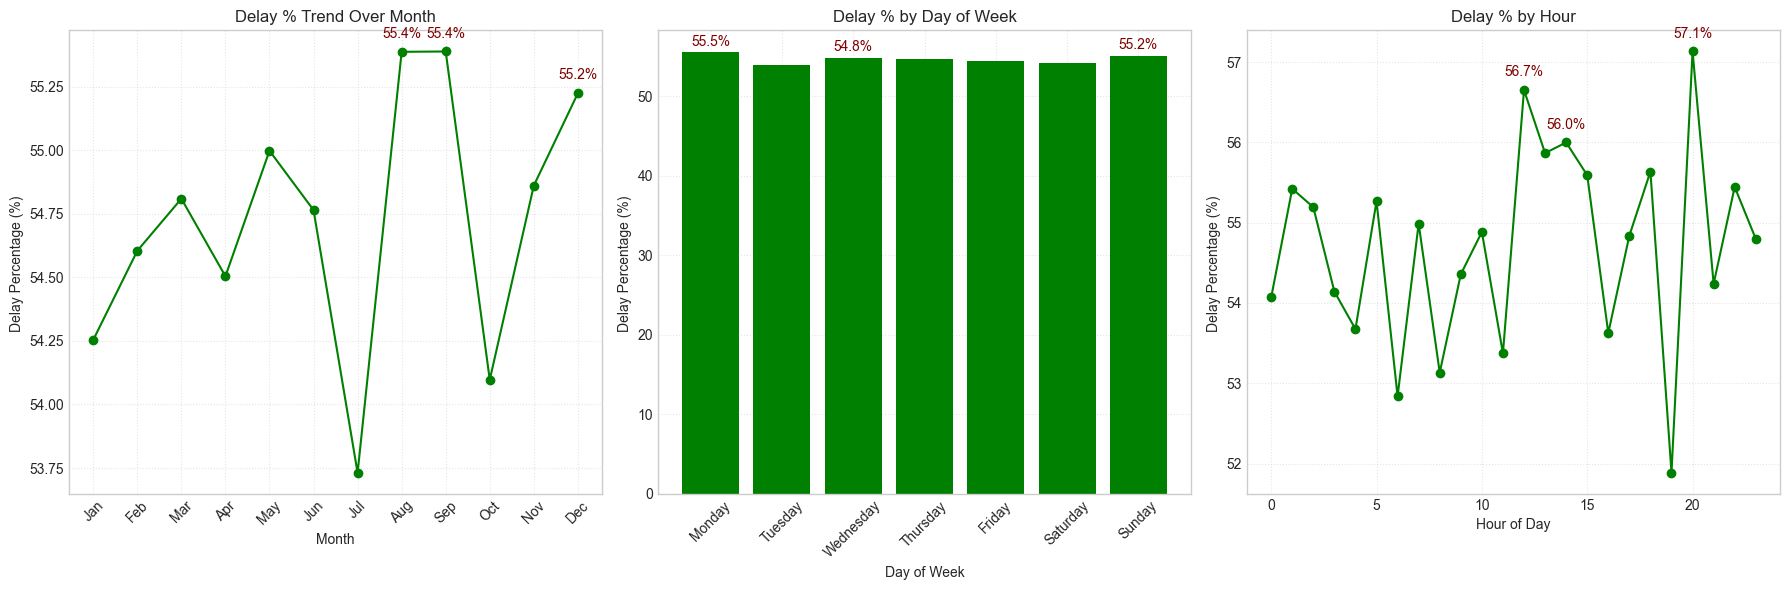

In [84]:
fig,(ax1,ax2,ax3) = plt.subplots(1,3,figsize=(18,6))

# Subplot 1: Delay % trend over month
ax1.plot(delay_by_month['order_month'], delay_by_month['delay_pct'], marker='o',color="green")
ax1.set_xticks(range(1,13))
ax1.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
ax1.set_xlabel("Month")
ax1.set_ylabel("Delay Percentage (%) ")
ax1.set_title("Delay % Trend Over Month")
ax1.grid(True, linestyle=':',alpha=0.5)

# Annotate top 3 highest
top3_month = delay_by_month.nlargest(3, 'delay_pct')
for _, row in top3_month.iterrows():
    ax1.annotate(f"{row['delay_pct']:.1f}%",(row['order_month'], row['delay_pct']),
                textcoords="offset points", xytext=(0,10), ha='center', fontsize=10, color=danger_color)

# Subplot 2: Delay % by Day of Week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
delay_by_day['order_day'] = pd.Categorical(delay_by_day['order_day'], categories=day_order,ordered=True)
delay_by_day = delay_by_day.sort_values('order_day')

ax2.bar(delay_by_day['order_day'], delay_by_day['delay_pct'], color="green")
ax2.set_xticklabels(delay_by_day['order_day'], rotation=45)
ax2.set_xlabel("Day of Week")
ax2.set_ylabel("Delay Percentage (%) ")
ax2.set_title("Delay % by Day of Week")
ax2.grid(True, linestyle=':',alpha=0.5)

# Annotate top 3 highest
top3_day = delay_by_day.nlargest(3, 'delay_pct')
for _, row in top3_day.iterrows():
    height = row['delay_pct']
    ax2.text(row['order_day'],height + 0.5, f'{height:.1f}%', ha='center', va='bottom', fontsize=10, color=danger_color)


# Subplot 3: Delay % by hour
ax3.plot(delay_by_hour['order_hour'], delay_by_hour['delay_pct'], marker='o',color="green")
ax3.set_xlabel("Hour of Day")
ax3.set_ylabel("Delay Percentage (%) ")
ax3.set_title("Delay % by Hour")
ax3.grid(True, linestyle=':',alpha=0.5)

# Annotate top 3 highest
top3_hour = delay_by_hour.nlargest(3, 'delay_pct')
for _, row in top3_hour.iterrows():
    ax3.annotate(f"{row['delay_pct']:.1f}%",(row['order_hour'], row['delay_pct']),
                textcoords="offset points", xytext=(0,10), ha='center', fontsize=10, color=danger_color)
plt.tight_layout()
plt.show()


Machine Learning Modeling

In [85]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from collections import Counter
from imblearn.over_sampling import SMOTE

In [86]:
X = df[['Type','Days for shipment (scheduled)','Category Name','Customer Segment','Department Name','Order Region','Shipping Mode','order_month','order_hour']]
y  = df['Late_delivery_risk'] 

In [87]:
cat_cols=X.select_dtypes(include=['object','category']).columns.tolist()
print('Categorical columns:',cat_cols)

# Frequency encoding (low-dimensionl and robust for high-cardinality)
for col in cat_cols:
    freq = X[col].value_counts(normalize=True)
    X[f'{col}_freq'] = X[col].map(freq)

# Keep numeric columns + new encoded features, drop original string categories
X_encoded = X.drop(columns=cat_cols)
print('Shape after freq+target encoding: ',X_encoded.shape)

# use encoded features for modeling
X = X_encoded

# train/test split after encoding
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=42, stratify=y
)

Categorical columns: ['Type', 'Category Name', 'Customer Segment', 'Department Name', 'Order Region', 'Shipping Mode']
Shape after freq+target encoding:  (172765, 9)


In [88]:
y.value_counts()

Late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64

In [89]:
# Balancing the training data set using SMOTE
print("Before balancing (train): ",Counter(y_train))

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("After balancing (train): ", Counter(y_train_bal))

Before balancing (train):  Counter({1: 79182, 0: 59030})
After balancing (train):  Counter({0: 79182, 1: 79182})


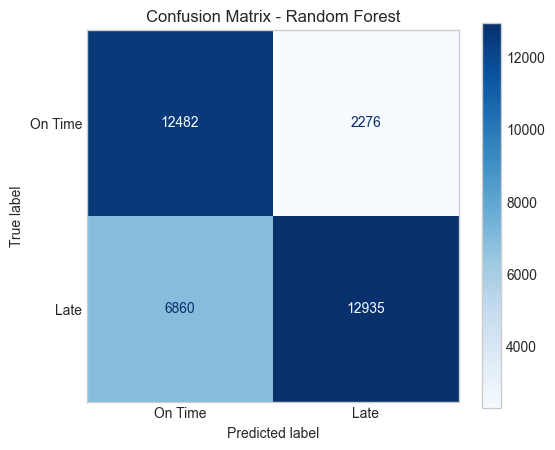

In [95]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf_balanced)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["On Time", "Late"]
)

fig, ax = plt.subplots(figsize=(6,5))
disp.plot(cmap="Blues", ax=ax)

plt.title("Confusion Matrix - Random Forest")
plt.grid(False)
plt.show()

In [90]:
def evaluate_model(y_true,y_pred,model_name):
    print(f"\n---- {model_name} -----")
    print("Accuracy: ", round(accuracy_score(y_true, y_pred),2))
    print("Precision: ", round(precision_score(y_true, y_pred),2))
    print("Recall: ",round(recall_score(y_true,y_pred),2))
    print("\nClassification Report: \n", classification_report(y_true, y_pred))

In [92]:
# Fit the Random State Model on balance data
rf_model_balanced = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
rf_model_balanced.fit(X_train_bal, y_train_bal)

y_pred_rf_balanced = rf_model_balanced.predict(X_test)

evaluate_model(y_test, y_pred_rf_balanced, "Random Forest Classifier")


---- Random Forest Classifier -----
Accuracy:  0.74
Precision:  0.85
Recall:  0.65

Classification Report: 
               precision    recall  f1-score   support

           0       0.65      0.85      0.73     14758
           1       0.85      0.65      0.74     19795

    accuracy                           0.74     34553
   macro avg       0.75      0.75      0.74     34553
weighted avg       0.76      0.74      0.74     34553



ROC-AUC Score: 0.822


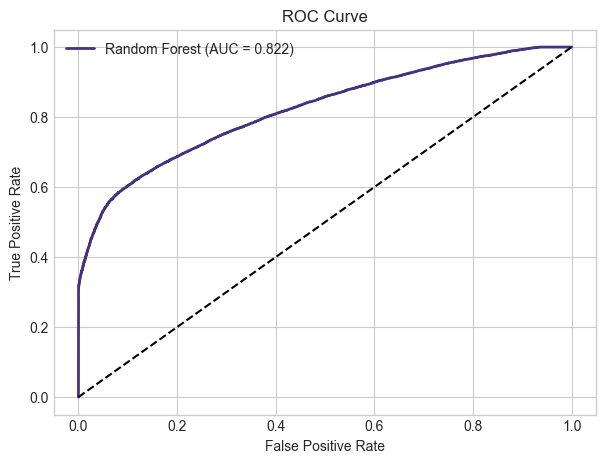

In [94]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predicted probabilities
y_prob = rf_model_balanced.predict_proba(X_test)[:,1]

# ROC AUC
auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score: {auc:.3f}")

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, linewidth=2,
         label=f"Random Forest (AUC = {auc:.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

                         Feature  Importance
0  Days for shipment (scheduled)    0.254740
8             Shipping Mode_freq    0.242023
2                     order_hour    0.167441
7              Order Region_freq    0.086202
1                    order_month    0.072279
4             Category Name_freq    0.071678
3                      Type_freq    0.043364
6           Department Name_freq    0.032837
5          Customer Segment_freq    0.029435


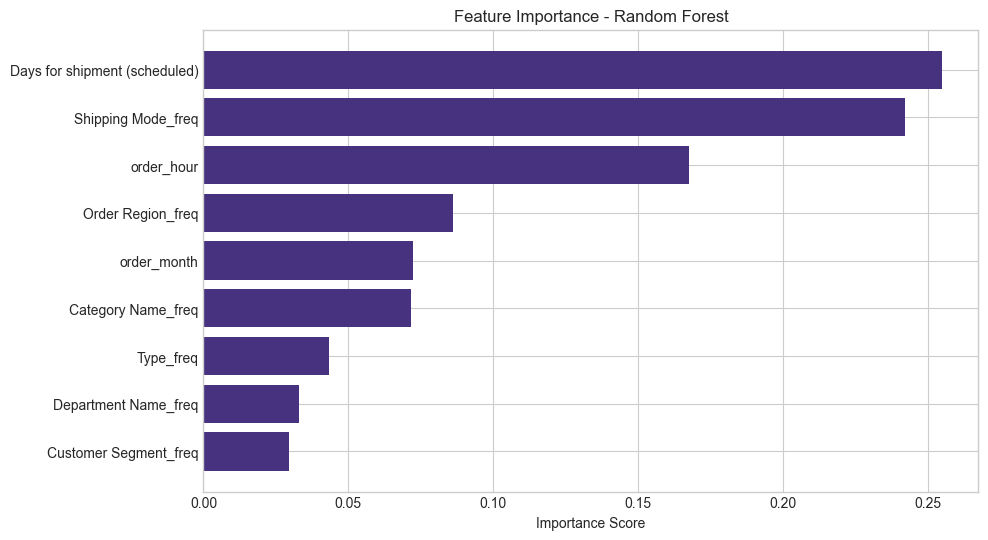

In [96]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model_balanced.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

plt.figure(figsize=(10,6))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.gca().invert_yaxis()

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")

plt.show()